In [15]:
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import PCA
from umap import UMAP
import plotly.graph_objects as go

In [4]:
import pandas as pd
import numpy as np
df = pd.read_csv('cleaned_abstracts.csv')
df

,abstracts
0,Indoor photovoltaics are promising to enable s...
1,The energy loss in perovskite solar cells (PSC...
2,Organic–inorganic hybrid perovskite solar cell...
3,Heavily Br-doped PSCs have a segregation-free ...
4,A novel biphenyl fumaronitrile as an acceptor ...
...,...
3366,The stability of encapsulated planar-structure...
3367,Perovskite solar cells (PSCs) with mesoporous ...
3368,"In recent years, there has been an unprecedent..."
3369,Wide bandgap (Eg) perovskite solar cells (PSCs...


In [5]:
import pandas as pd

# Load your CSV
df = pd.read_csv('cleaned_abstracts.csv')

# Drop NaN or empty abstracts BEFORE embedding
df_clean = df.dropna().copy()
df_clean = df_clean[df_clean['abstracts'].str.strip().astype(bool)].reset_index(drop=True)

# Now df_clean.shape[0] should match embeddings.shape[0]
print(df_clean.shape)

(3371, 1)


In [38]:
import torch

# Dynamic device selection
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [8]:
df.shape

(3371, 1)

In [9]:
# embedding = np.load("stella_encoded_data.npy")
embedding = np.load("stella_embeddings.npy")

embedding.shape

(3371, 1024)

In [10]:
embedding[0]

array([-0.22475423,  0.34246272, -0.0339629 , ...,  0.07205345,
       -0.02839921, -0.11450056], shape=(1024,), dtype=float32)

In [17]:
# remember that the best so far was 55 
reducer = UMAP(n_components=55,random_state=42)
reduced_data  = reducer.fit_transform(embedding)

/home/yummareddy/anaconda3/envs/hiwi/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [18]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

In [19]:
embedding.shape

(3371, 1024)

In [20]:
reduced_data.shape

(3371, 55)

In [21]:
# remember that the best so far was 55 (For Agglomerative Clustering)
pca = PCA(n_components=55,random_state=42)
X_reduced = pca.fit_transform(embedding)

In [22]:
embedding.shape

(3371, 1024)

In [23]:
X_reduced.shape

(3371, 55)

In [24]:
linkage_matrix = linkage(X_reduced, method='ward')

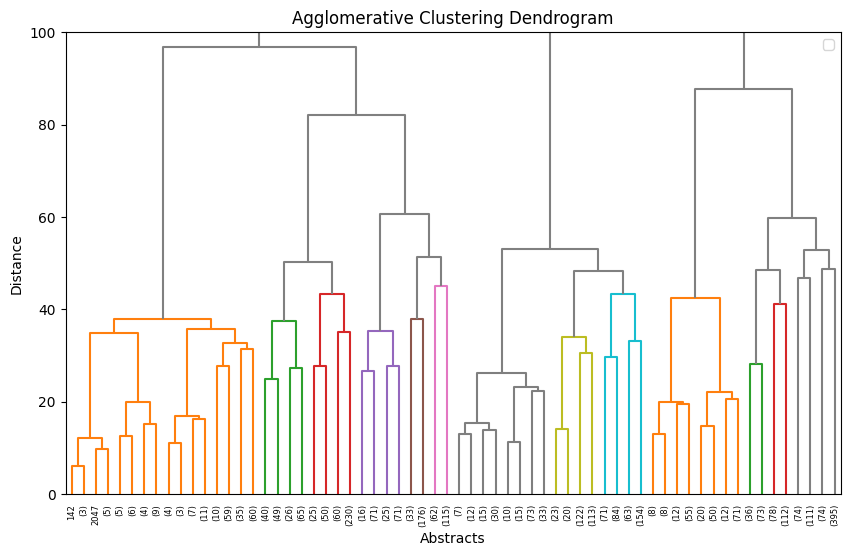

In [26]:
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage

# Agglomerative clustering
clusterer = AgglomerativeClustering(n_clusters=15, linkage='ward')

# Create linkage matrix directly from the data (Ward method)
linkage_matrix = linkage(X_reduced, method='ward')

# Calculate correct threshold for 15 clusters
threshold_index = len(X_reduced) - 15 - 1
distance_threshold = linkage_matrix[threshold_index, 2]

plt.figure(figsize=(10, 6))

# above_threshold_color='gray' to show merged clusters
dendrogram(linkage_matrix, 
           truncate_mode='level', 
           p=5, 
           color_threshold=distance_threshold, 
           above_threshold_color='gray')        

plt.title("Agglomerative Clustering Dendrogram")
plt.xlabel("Abstracts")
plt.ylabel("Distance")
plt.legend()  
plt.ylim(0, 100)
plt.show()

In [27]:
import pandas as pd
import numpy as np
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import PCA
from umap import UMAP
import plotly.graph_objects as go

# ============================================================
# CONFIG
# ============================================================

INPUT_FILE = "cleaned_abstracts.csv"
N_CLUSTERS = 15
DENDROGRAM_LEVELS = 5
n_components = 55  


STOPWORDS = {
    'a','an','the','of','for','with','on','at','by','from','to','i',
    'and','or','but','as','is','are','was','were','be','been','being',
    'have','has','had','can','will','would','could','should',
    'this','that','these','those','which','their','our','its',
    'using','used','use','based','showed','shown','show','we'
}

# ============================================================
# 1. LOAD DATA
# ============================================================

df = pd.read_csv(INPUT_FILE)
abstracts = df["abstracts"].tolist()
n_abstracts = len(abstracts)

# ============================================================
# 2. AGGLOMERATIVE CLUSTERING
# ============================================================

vectorizer = TfidfVectorizer(max_features=1000, stop_words="english")
X = vectorizer.fit_transform(abstracts)

pca = PCA(n_components=55)
X_reduced = pca.fit_transform(embedding)

clusterer = AgglomerativeClustering(
    n_clusters=N_CLUSTERS,
    linkage="ward"
)
cluster_labels = clusterer.fit_predict(X_reduced)

linkage_matrix = linkage(X_reduced, method="ward")

threshold_index = len(X_reduced) - N_CLUSTERS - 1
distance_threshold = linkage_matrix[threshold_index, 2]

# ============================================================
# 3. BUILD FULL TREE
# ============================================================

node_members = {i: [i] for i in range(n_abstracts)}

for merge_idx, (l, r, _, _) in enumerate(linkage_matrix):
    node_id = n_abstracts + merge_idx
    node_members[node_id] = node_members[int(l)] + node_members[int(r)]

# Parent–child relations
merge_children = {}
merge_parent = {}

for merge_idx, (l, r, _, _) in enumerate(linkage_matrix):
    merge_children[merge_idx] = (int(l), int(r))
    if l >= n_abstracts:
        merge_parent[l - n_abstracts] = merge_idx
    if r >= n_abstracts:
        merge_parent[r - n_abstracts] = merge_idx

# ============================================================
# 4. DENDROGRAM
# ============================================================

dend = dendrogram(
    linkage_matrix,
    truncate_mode="level",
    p=DENDROGRAM_LEVELS,
    color_threshold=distance_threshold,
    no_plot=True
)

icoord = dend["icoord"]
dcoord = dend["dcoord"]

# ============================================================
# 5. SIBLING-AWARE c-TF-IDF
# ============================================================

def extract_keywords(node_indices, sibling_indices_list):
    node_doc = " ".join(abstracts[i] for i in node_indices)

    if not sibling_indices_list:
        tfidf = TfidfVectorizer(
            stop_words=list(STOPWORDS),
            ngram_range=(1, 3),
            max_features=500
        )
        scores = tfidf.fit_transform([node_doc]).toarray()[0]
        terms = tfidf.get_feature_names_out()
        top = scores.argsort()[-10:][::-1]
        return [terms[i] for i in top if scores[i] > 0]

    sibling_docs = [
        " ".join(abstracts[i] for i in sib)
        for sib in sibling_indices_list
    ]

    vectorizer = CountVectorizer(
        stop_words=list(STOPWORDS),
        ngram_range=(1, 3),
        max_features=1500
    )

    mat = vectorizer.fit_transform([node_doc] + sibling_docs)
    terms = vectorizer.get_feature_names_out()

    node_tf = mat[0].toarray().flatten()
    sib_tf = mat[1:].toarray()

    node_freq = node_tf / (node_tf.sum() + 1)
    sib_freq = sib_tf.mean(axis=0) / (sib_tf.sum(axis=1).mean() + 1)

    score = node_freq - sib_freq
    top = score.argsort()[-20:][::-1]

    return [
        terms[i] for i in top
        if score[i] > 0 and node_tf[i] >= 2
    ]

# ============================================================
# 6. UNIQUE LABEL GENERATION
# ============================================================

def make_label(keywords, used):
    if not keywords:
        return "General Research"

    phrases = [k for k in keywords if " " in k]
    singles = [k for k in keywords if " " not in k]

    def cap(w): return w.title()

    for p in phrases:
        label = " ".join(cap(w) for w in p.split())
        if label not in used:
            return label

    for i in range(min(5, len(singles)-1)):
        label = f"{cap(singles[i])} {cap(singles[i+1])}"
        if label not in used:
            return label

    base = cap(singles[0])
    k = 1
    while f"{base} {k}" in used:
        k += 1
    return f"{base} {k}"

# ============================================================
# 7. MAP VISIBLE NODES + UNIQUE LABELS + CLUSTER INFO
# ============================================================

visible_nodes = []
used_labels = set()

for xs, ys in zip(icoord, dcoord):
    h = max(ys)
    x = (xs[1] + xs[2]) / 2

    candidates = []
    for i, (_, _, dist, _) in enumerate(linkage_matrix):
        if abs(dist - h) < 1e-3:
            node_id = n_abstracts + i
            candidates.append((node_id, node_members[node_id]))

    if not candidates:
        continue

    node_id, members = max(candidates, key=lambda x: len(x[1]))

    siblings = []
    merge_idx = node_id - n_abstracts
    if merge_idx in merge_parent:
        p = merge_parent[merge_idx]
        l, r = merge_children[p]
        for s in (l, r):
            if s != node_id and s in node_members:
                siblings.append(node_members[s])

    keywords = extract_keywords(members, siblings)
    label = make_label(keywords, used_labels)
    used_labels.add(label)

    visible_nodes.append(dict(
        x=x,
        y=h,
        label=label,
        keywords=keywords,
        n=len(members),
        clusters=sorted(set(cluster_labels[i] for i in members)),
        samples=[abstracts[i][:200] for i in members[:5]]
    ))

# ============================================================
# 8. PLOTLY DENDROGRAM WITH CLUSTER AND ABSTRACT INFO
# ============================================================

fig = go.Figure()

for x, y in zip(icoord, dcoord):
    fig.add_trace(go.Scatter(
        x=x, y=y, mode="lines",
        line=dict(color="gray", width=1),
        hoverinfo="skip",
        showlegend=False
    ))

for n in visible_nodes:
    fig.add_trace(go.Scatter(
        x=[n["x"]], y=[n["y"]],
        mode="markers+text",
        marker=dict(size=7),
        text=n["label"],
        textposition="top center",
        hovertext=(
            f"<b>{n['label']}</b><br>"
            f"Number of Abstracts: {n['n']}<br>"
            f"Cluster(s): {n['clusters']}<br><br>"
            f"<b>All c-TF-IDF keywords:</b><br>"
            + ", ".join(n["keywords"]) +
            "<br><br>" +
            "<br>".join(n["samples"])
        ),
        hoverinfo="text",
        showlegend=False
    ))

fig.update_layout(
    title="Agglomerative Dendrogram with Unique Automatic Labels",
    xaxis=dict(showticklabels=False),
    yaxis=dict(title="Distance"),
    width=2200,
    height=1100
)

fig.write_html("interactive_dendrogram_full keywords.html", auto_open=True)

In [31]:
import re, time, pickle
from pathlib import Path
import requests
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from tools import post_data
from project_variable import variables

DATA_FILE        = "doi_list_meta_data.json"
NEW_PAPERS_CACHE = "new_nomad_papers.csv"
OUTPUT_FILE      = "similar_abstracts_from_nomad.csv"
MAX_NEW_PAGES    = 5
TOP_N            = 5

def clean_text(text):
    if not isinstance(text, str): return ""
    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"&[a-z]+;", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

print("Imports done")

Imports done


In [32]:
import os

# See where Jupyter is currently running from
print("Current folder:", os.getcwd())

# Change to the folder where tools.py lives
os.chdir("/home/yummareddy/Literature-Integration-Prototype/embeddings_clustering/")  # change this to your actual path

# Now the import will work
from tools import post_data
from project_variable import variables

Current folder: /home/yummareddy/Literature-Integration-Prototype/embeddings_clustering


In [33]:
df_query = pd.read_json("doi_list_meta_data.json")
df_query = df_query[df_query["abstract"].notna()].copy()
df_query = df_query[df_query["abstract"].str.strip() != ""].copy()
df_query["abstract_clean"] = df_query["abstract"].apply(clean_text)
df_query = df_query[df_query["abstract_clean"].str.len() > 50].reset_index(drop=True)
existing_dois = set(df_query["doi"].dropna().str.strip().str.lower().tolist())
print(f"Query papers loaded: {len(df_query)}")

Query papers loaded: 3371


In [34]:
def fetch_abstract_from_crossref(doi):
    try:
        r   = requests.get(f"https://api.crossref.org/works/{doi}", timeout=10)
        msg = r.json().get("message", {})
        title    = (msg.get("title") or [""])[0]
        abstract = clean_text(msg.get("abstract", "") or "")
        return title, abstract
    except:
        return "", ""

def fetch_new_nomad_papers():
    new_dois, page_value = [], None
    for page_num in range(1, MAX_NEW_PAGES + 1):
        data = {
            "owner": "visible",
            "query": {"and": [{}, {"sections:all": ["nomad.datamodel.results.SolarCell"]}]},
            "aggregations": {},
            "pagination": {
                "order_by": "results.properties.optoelectronic.solar_cell.efficiency",
                "order": "desc", "page_size": 1000, "page_after_value": page_value
            },
            "required": {"exclude": ["quantities", "sections", "files"]}
        }
        response  = post_data(variables["POST_META_DATA"], data)
        next_page = response["pagination"].get("next_page_after_value")
        for entry in response.get("data", []):
            refs = entry.get("references", [])
            if refs:
                doi = refs[0].strip().lower()
                if doi and doi not in existing_dois:
                    new_dois.append(doi)
        print(f"  Page {page_num}: {len(new_dois)} new DOIs...")
        if not next_page: break
        page_value = next_page

    new_dois = list(set(new_dois))
    print(f"Fetching {len(new_dois)} abstracts via CrossRef...")
    papers = []
    for i, doi in enumerate(new_dois):
        if i % 50 == 0: print(f"  {i} / {len(new_dois)} ...")
        title, abstract = fetch_abstract_from_crossref(doi)
        if abstract and len(abstract) > 50:
            papers.append({"doi": doi, "title": title, "abstract": abstract})
        time.sleep(0.1)
    df_new = pd.DataFrame(papers)
    df_new.to_csv(NEW_PAPERS_CACHE, index=False)
    print(f"Saved {len(df_new)} papers to {NEW_PAPERS_CACHE}")
    return df_new

if Path(NEW_PAPERS_CACHE).exists():
    print("Loading cached NOMAD papers...")
    df_nomad = pd.read_csv(NEW_PAPERS_CACHE)
else:
    df_nomad = fetch_new_nomad_papers()

# Always rebuild these two columns
df_nomad["abstract_clean"] = df_nomad["abstract"].apply(clean_text)
df_nomad["doi_link"]       = "https://doi.org/" + df_nomad["doi"].astype(str)
df_nomad = df_nomad[df_nomad["abstract_clean"].str.len() > 50].reset_index(drop=True)
print(f"New NOMAD papers ready: {len(df_nomad)}")

Loading cached NOMAD papers...
New NOMAD papers ready: 1284


In [36]:
vectorizer = TfidfVectorizer(max_features=1000, stop_words="english",
                              ngram_range=(1,2), sublinear_tf=True)
nomad_matrix = vectorizer.fit_transform(df_nomad["abstract_clean"].tolist())
print(f"Matrix: {nomad_matrix.shape}")

all_results = []
for i in range(len(df_query)):
    if i % 200 == 0: print(f"  Processing {i} / {len(df_query)} ...")
    query_vec = vectorizer.transform([df_query.loc[i, "abstract_clean"]])
    scores    = cosine_similarity(query_vec, nomad_matrix).flatten()
    top_idx   = scores.argsort()[::-1][:TOP_N]
    for rank, idx in enumerate(top_idx, start=1):
        score = float(scores[idx])
        if score <= 0: break
        all_results.append({
            "query_index"      : i,
            "query_doi"        : df_query.loc[i, "doi"],
            "query_title"      : df_query.loc[i, "title"],
            "query_abstract"   : df_query.loc[i, "abstract_clean"][:300],
            "rank"             : rank,
            "similarity_score" : round(score, 4),
            "nomad_doi"        : df_nomad.loc[idx, "doi"],
            "nomad_doi_link"   : df_nomad.loc[idx, "doi_link"],
            "nomad_title"      : df_nomad.loc[idx, "title"],
            "nomad_abstract"   : df_nomad.loc[idx, "abstract_clean"][:300],
        })

results_df = pd.DataFrame(all_results)
results_df.to_csv(OUTPUT_FILE, index=False)
print(f"\nDone! {len(results_df)} rows saved to {OUTPUT_FILE}")
print(results_df[["query_title","rank","similarity_score","nomad_title"]].head(10).to_string(index=False))

Matrix: (1284, 1000)
  Processing 0 / 3371 ...
  Processing 200 / 3371 ...
  Processing 400 / 3371 ...
  Processing 600 / 3371 ...
  Processing 800 / 3371 ...
  Processing 1000 / 3371 ...
  Processing 1200 / 3371 ...
  Processing 1400 / 3371 ...
  Processing 1600 / 3371 ...
  Processing 1800 / 3371 ...
  Processing 2000 / 3371 ...
  Processing 2200 / 3371 ...
  Processing 2400 / 3371 ...
  Processing 2600 / 3371 ...
  Processing 2800 / 3371 ...
  Processing 3000 / 3371 ...
  Processing 3200 / 3371 ...

Done! 16850 rows saved to similar_abstracts_from_nomad.csv
                                                                                                                                                 query_title  rank  similarity_score                                                                                                                                                             nomad_title
             Tailoring Triple‐Anion Perovskite Material for Indoor Light Harvesting 

In [37]:
def show_similar_for(query):
    if isinstance(query, int):
        subset = results_df[results_df["query_index"] == query]
        print(f"\nPaper #{query}: {df_query.loc[query, 'title']}")
    else:
        subset = results_df[results_df["query_doi"] == query]
        print(f"\nDOI: {query}")
    print(f"\n--- {len(subset)} similar abstracts from NOMAD ---\n")
    for _, row in subset.iterrows():
        print(f"[{int(row['rank'])}] Score : {row['similarity_score']}")
        print(f"     Title : {row['nomad_title']}")
        print(f"     Link  : {row['nomad_doi_link']}")
        print(f"     Abstract: {row['nomad_abstract'][:200]}...")
        print()

show_similar_for(0)


Paper #0: Tailoring Triple‐Anion Perovskite Material for Indoor Light Harvesting with Restrained Halide Segregation and Record High Efficiency Beyond 36%

--- 5 similar abstracts from NOMAD ---

[1] Score : 0.9489
     Title : Tailoring Triple‐Anion Perovskite Material for Indoor Light Harvesting with Restrained Halide Segregation and Record High Efficiency Beyond 36%
     Link  : https://doi.org/https://doi.org/10.1002/aenm.201901980
     Abstract: Abstract Indoor photovoltaics are promising to enable self‐powered electronic devices for the Internet of Things. Here, reported is a triple‐anion CH 3 NH 3 PbI 2− x BrCl x perovskite film, of which t...

[2] Score : 0.252
     Title : Dipolar cations confer defect tolerance in wide-bandgap metal halide perovskites
     Link  : https://doi.org/https://doi.org/10.1038/s41467-018-05531-8
     Abstract: Abstract Efficient wide-bandgap perovskite solar cells (PSCs) enable high-efficiency tandem photovoltaics when combined with crystalline sili